# ARTI404 – Image Processing
## Lab 6 – Assessment: Sobel Filter in the Frequency Domain

**Task:** Apply the Sobel filter(s) in the frequency domain on the Cameraman image and show the results.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift, fftshift

## 2. Load and Resize the Cameraman Image

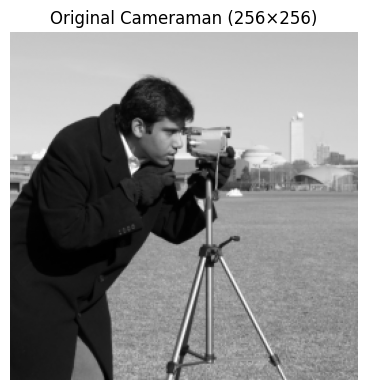

Image shape: (256, 256)


In [2]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256), anti_aliasing=True)  # Resize for faster FFT

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman (256×256)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {image.shape}')

## 3. Define Sobel Filters (Spatial Domain)

In [3]:
# Sobel filters — detect horizontal and vertical edges
sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]], dtype=np.float64)   # Detects vertical edges

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)   # Detects horizontal edges

print('Sobel X kernel (vertical edges):')
print(sobel_x)
print()
print('Sobel Y kernel (horizontal edges):')
print(sobel_y)

Sobel X kernel (vertical edges):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Sobel Y kernel (horizontal edges):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


## 4. Helper: Center-Embed Kernel and Compute Its FFT

To apply a small spatial kernel via the frequency domain, we must:
1. Pad the kernel to match the image size
2. Center it at the image origin (top-left) using `ifftshift` before taking the FFT

This ensures correct phase alignment (no spatial shift artifacts).

In [4]:
def center_embed_kernel(kernel, shape):
    """
    Embed a small kernel into a zero-padded array of `shape`,
    centered in the array, then shift to top-left and return its FFT.

    Parameters
    ----------
    kernel : 2D numpy array
        The small spatial filter kernel.
    shape  : tuple (H, W)
        Target shape (must match the image size).

    Returns
    -------
    2D complex numpy array — the FFT of the padded, shifted kernel.
    """
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    # Center coordinates
    cy, cx = ph // 2, pw // 2

    # Insert kernel centered at the image center
    padded[cy - kh//2 : cy - kh//2 + kh,
           cx - kw//2 : cx - kw//2 + kw] = kernel

    # ifftshift moves (0,0) to top-left before FFT — required for correct convolution
    return fft2(ifftshift(padded))

## 5. Apply Sobel Filters in the Frequency Domain

In [5]:
# --- FFT of the image ---
F = fft2(image)

# --- FFT of the centered Sobel kernels ---
H_x = center_embed_kernel(sobel_x, image.shape)  # Frequency response of Sobel X
H_y = center_embed_kernel(sobel_y, image.shape)  # Frequency response of Sobel Y

# --- Multiply in the frequency domain (= convolution in spatial domain) ---
G_x = F * H_x
G_y = F * H_y

# --- Inverse FFT to recover spatial results ---
sobel_x_result = ifft2(G_x).real
sobel_y_result = ifft2(G_y).real

# --- Gradient magnitude ---
sobel_magnitude = np.sqrt(sobel_x_result**2 + sobel_y_result**2)

print('Computation complete.')
print(f'Sobel X result range: [{sobel_x_result.min():.3f}, {sobel_x_result.max():.3f}]')
print(f'Sobel Y result range: [{sobel_y_result.min():.3f}, {sobel_y_result.max():.3f}]')
print(f'Gradient magnitude range: [{sobel_magnitude.min():.3f}, {sobel_magnitude.max():.3f}]')

Computation complete.
Sobel X result range: [-3.180, 3.303]
Sobel Y result range: [-2.979, 2.665]
Gradient magnitude range: [0.000, 3.448]


## 6. Visualize the Results

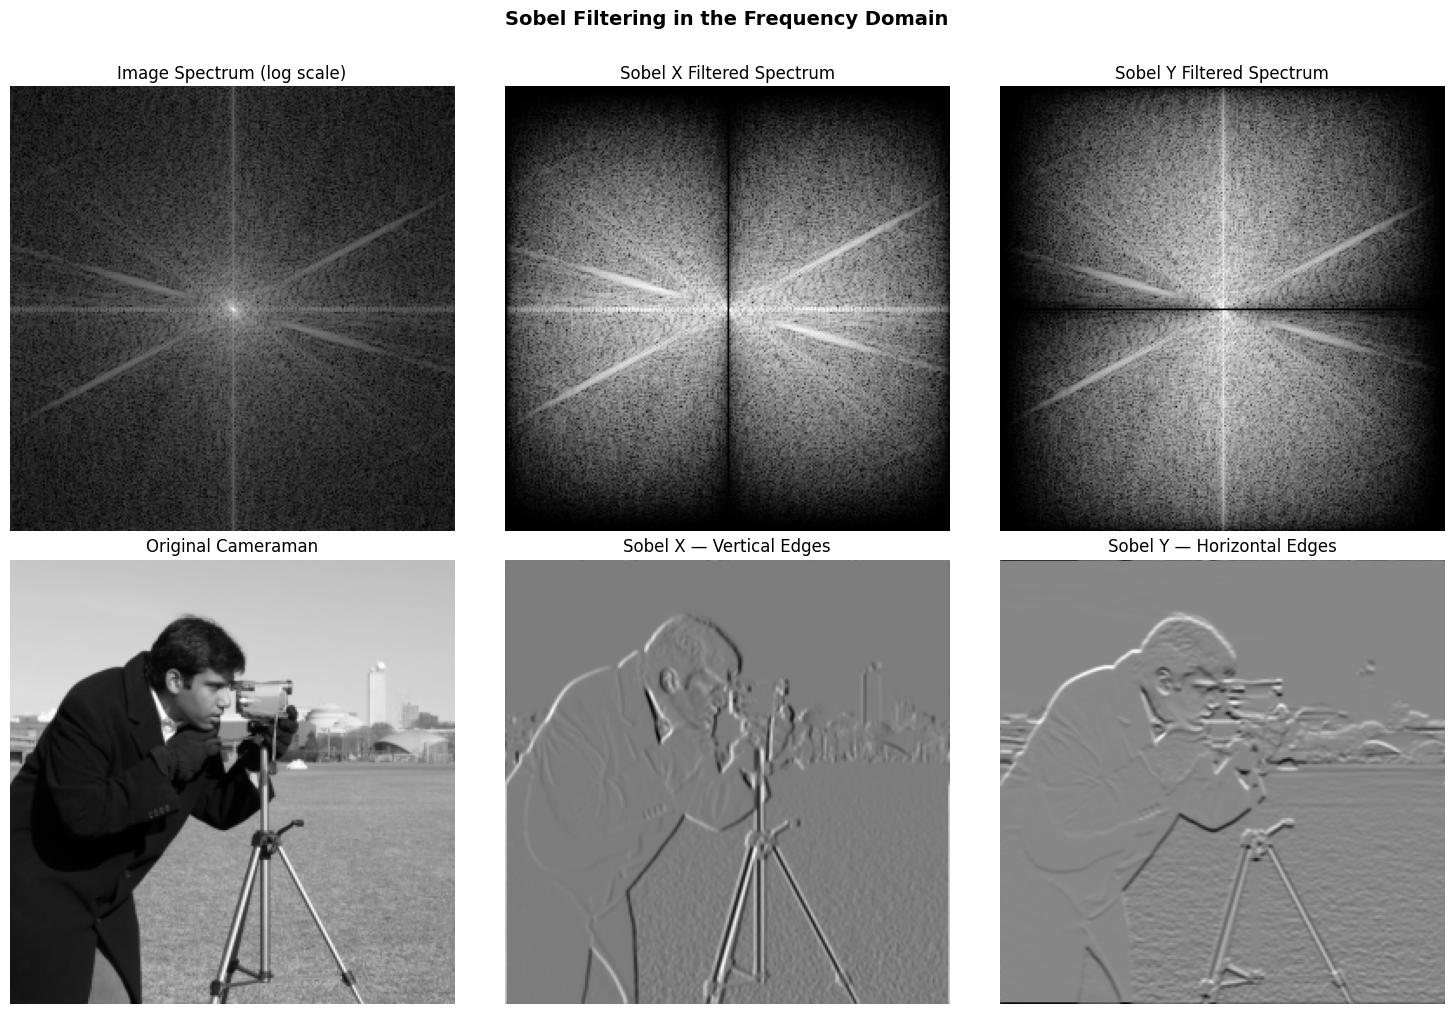

Figure saved as sobel_frequency_domain.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- Row 1: Frequency domain spectra ---
axes[0, 0].imshow(np.log(1 + np.abs(fftshift(F))), cmap='gray')
axes[0, 0].set_title('Image Spectrum (log scale)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(np.log(1 + np.abs(fftshift(G_x))), cmap='gray')
axes[0, 1].set_title('Sobel X Filtered Spectrum', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(np.log(1 + np.abs(fftshift(G_y))), cmap='gray')
axes[0, 2].set_title('Sobel Y Filtered Spectrum', fontsize=12)
axes[0, 2].axis('off')

# --- Row 2: Spatial domain results ---
axes[1, 0].imshow(image, cmap='gray')
axes[1, 0].set_title('Original Cameraman', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_x_result, cmap='gray')
axes[1, 1].set_title('Sobel X — Vertical Edges', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_y_result, cmap='gray')
axes[1, 2].set_title('Sobel Y — Horizontal Edges', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Sobel Filtering in the Frequency Domain', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sobel_frequency_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as sobel_frequency_domain.png')

## 8. Summary

| Step | Operation |
|------|-----------|
| 1 | Load the Cameraman image and resize to 256×256 |
| 2 | Define Sobel X and Sobel Y kernels (3×3) |
| 3 | Pad and center each kernel to 256×256, apply `ifftshift` before FFT |
| 4 | Compute 2D FFT of the image: **F** |
| 5 | Multiply **F** by each kernel's FFT: **G_x = F · H_x**, **G_y = F · H_y** |
| 6 | Apply inverse FFT to get the filtered spatial images |

**Key insight:** Convolution in the spatial domain is equivalent to pointwise multiplication in the frequency domain (Convolution Theorem). The `ifftshift` step before the kernel's FFT is critical — it relocates the kernel's center to coordinate (0,0), matching NumPy's FFT convention and avoiding phase-shift artifacts.